### Churn Modelling Project 

#### Introduction

##### Customer churn is a major problem in the banking sector where customers leave a bank and move to a competitor. This project focuses on analyzing customer data to understand the key factors that influence churn and to build a machine learning model that can predict whether a customer is likely to leave the bank.

##### The dataset used in this project contains customer demographic and financial information such as age, balance, credit score, geography, and activity status. Data preprocessing techniques are applied to clean the dataset and encode categorical variables.

##### A classification model is trained to predict customer churn, and feature importance analysis is performed to identify the most influential factors affecting customer retention.

###### The goal of this project is to help businesses improve customer retention strategies by identifying high-risk customers in advance.

####  Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#### Step 2: Load Dataset

In [9]:
import zipfile

with zipfile.ZipFile(r"C:\Users\arft\Downloads\Churn Modelling.zip", 'r') as zip_ref:
    zip_ref.extractall(r"C:\Users\arft\Downloads")

In [11]:
df = pd.read_csv(r"C:\Users\arft\Downloads\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### Step 3: Data Cleaning

In [12]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [13]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### Step 4: Encode Categorical Data

In [14]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [15]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

#### Step 5: Define Features & Target

In [16]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

#### Step 6: Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

####  Step 7: Train Classification Model

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

####  Step 8: Predictions

In [19]:
y_pred = model.predict(X_test)

####  Step 9: Model Evaluation

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.866
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



####  Step 10: Feature Importance Analysis

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)

              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268


#### Step 11: Visualize Feature Importance

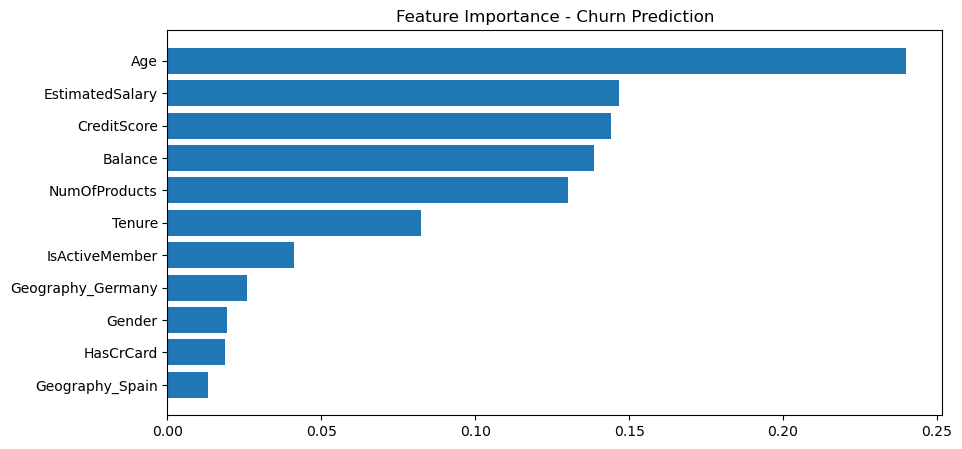

In [22]:
plt.figure(figsize=(10,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Churn Prediction")
plt.show()

### Age Distribution

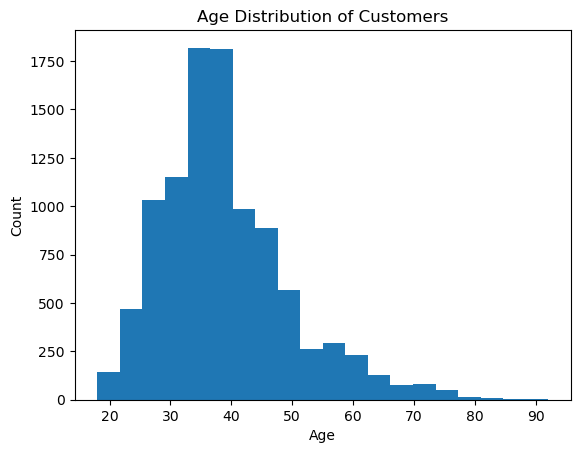

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### Age vs Churn

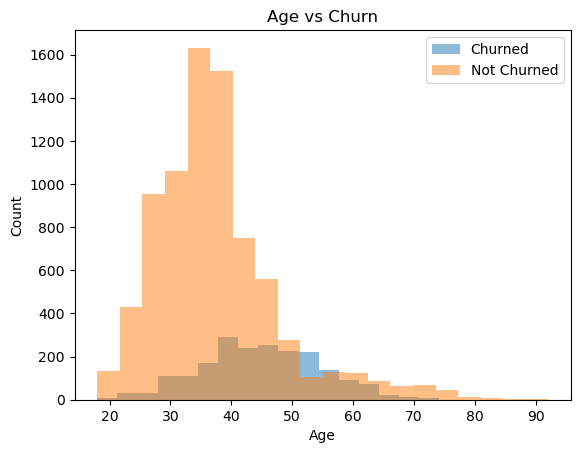

In [24]:
churned = df[df["Exited"] == 1]["Age"]
not_churned = df[df["Exited"] == 0]["Age"]

plt.figure()
plt.hist(churned, bins=20, alpha=0.5, label="Churned")
plt.hist(not_churned, bins=20, alpha=0.5, label="Not Churned")

plt.title("Age vs Churn")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

#### Average Age by Churn Group

In [25]:
import pandas as pd

age_summary = df.groupby("Exited")["Age"].mean()
print(age_summary)

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64


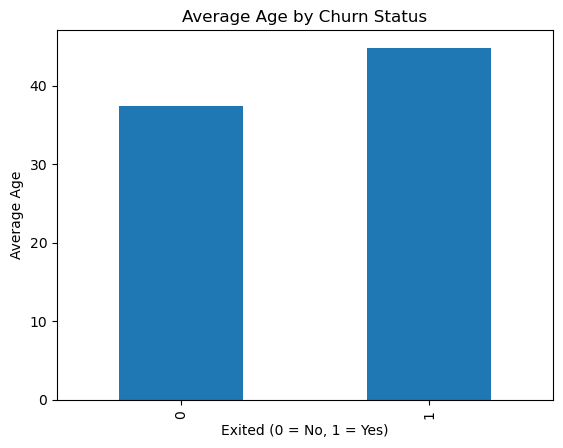

In [26]:
plt.figure()
age_summary.plot(kind="bar")
plt.title("Average Age by Churn Status")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Average Age")
plt.show()

#### Age Group Analysis 

C:\Users\arft\AppData\Local\Temp\ipykernel_2636\1045219990.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby(["AgeGroup", "Exited"]).size().unstack()


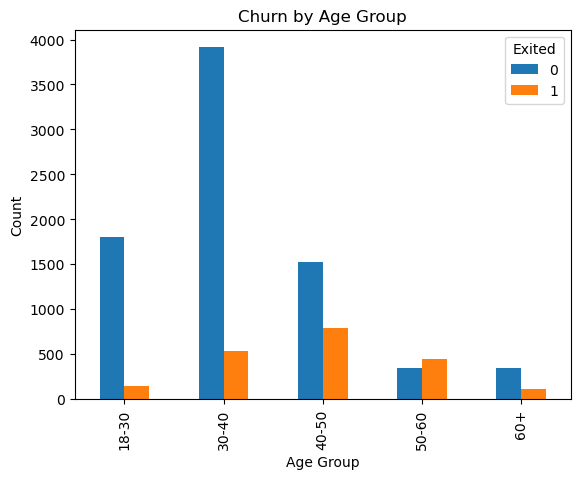

In [27]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[18,30,40,50,60,100], 
                        labels=["18-30","30-40","40-50","50-60","60+"])

age_churn = df.groupby(["AgeGroup", "Exited"]).size().unstack()

age_churn.plot(kind="bar")
plt.title("Churn by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

### Churn Count

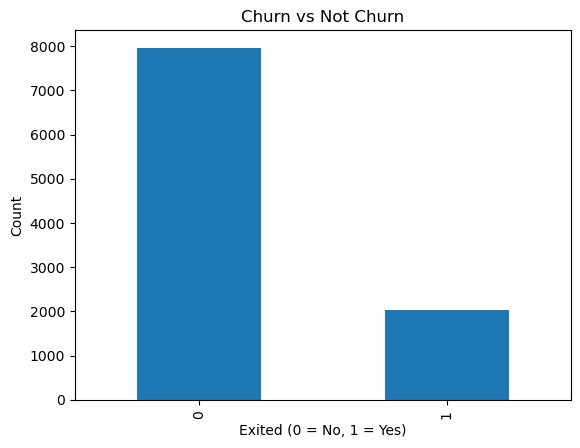

In [28]:
import matplotlib.pyplot as plt

churn_counts = df["Exited"].value_counts()

plt.figure()
churn_counts.plot(kind="bar")
plt.title("Churn vs Not Churn")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

#### Gender vs Churn

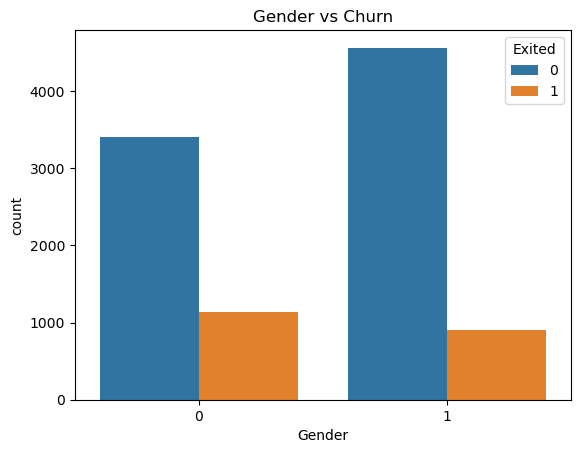

In [30]:
plt.figure()
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender vs Churn")
plt.show()

#### Credit Score vs Churn 

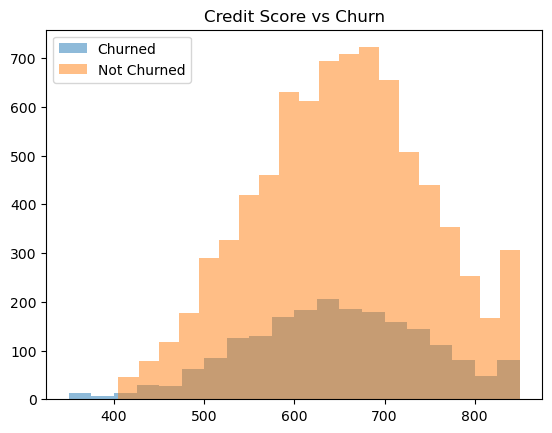

In [31]:
plt.figure()
plt.hist(df[df["Exited"]==1]["CreditScore"], bins=20, alpha=0.5, label="Churned")
plt.hist(df[df["Exited"]==0]["CreditScore"], bins=20, alpha=0.5, label="Not Churned")

plt.title("Credit Score vs Churn")
plt.legend()
plt.show()

#### Balance vs Churn 

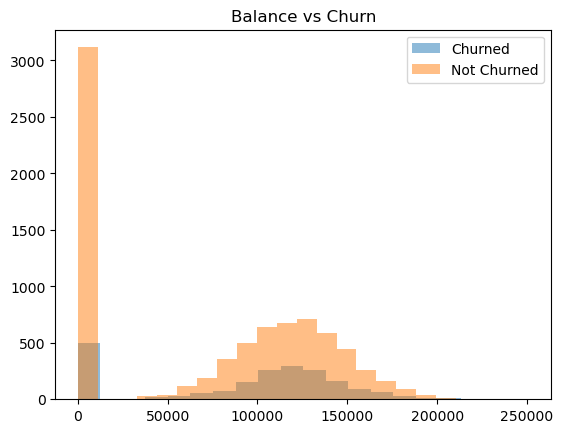

In [32]:
plt.figure()
plt.hist(df[df["Exited"]==1]["Balance"], bins=20, alpha=0.5, label="Churned")
plt.hist(df[df["Exited"]==0]["Balance"], bins=20, alpha=0.5, label="Not Churned")

plt.title("Balance vs Churn")
plt.legend()
plt.show()

#### IsActiveMember vs Churn 

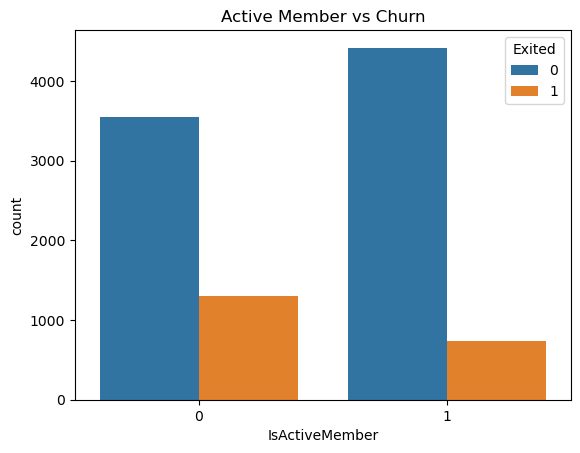

In [33]:
plt.figure()
sns.countplot(x="IsActiveMember", hue="Exited", data=df)
plt.title("Active Member vs Churn")
plt.show()


#### Correlation Heatmap

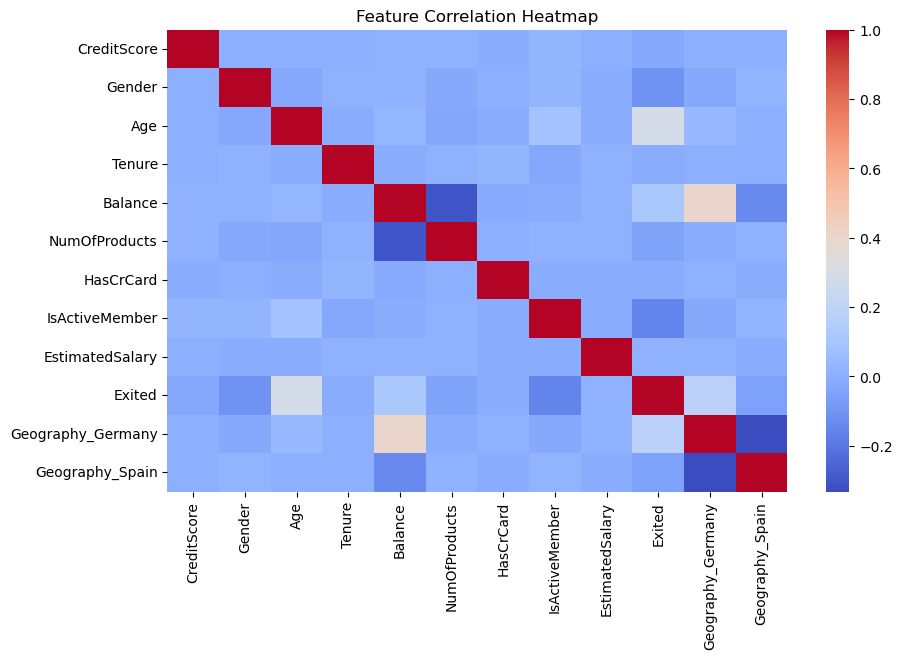

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

#### Conclusion

##### The model predicts customer churn effectively and helps identify key factors such as age, balance, and activity status.
##### These insights can help banks improve customer retention and reduce churn rate using data-driven decisions.